Install Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load Dataset

In [8]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Dataset Overview

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Missing Values

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Records

In [15]:
df.duplicated().sum()

np.int64(0)

Data Type Fix

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Fill Missing Values

In [17]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\chinn\AppData\Local\Temp\ipykernel_18780\1479199042.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

Remove Customer ID

In [18]:
df.drop("customerID", axis=1, inplace=True)

Numerical Summary

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Chart 1
Churn Count

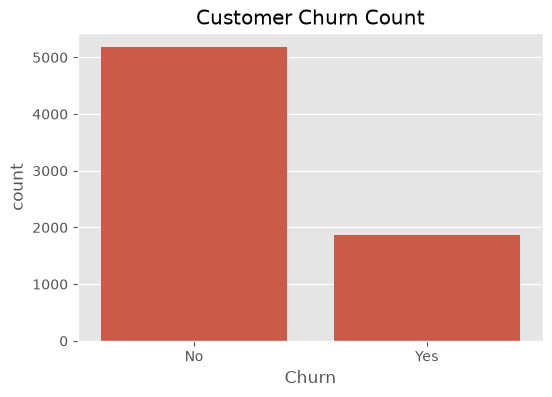

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Count")
plt.show()

Chart 2
Pie Chart

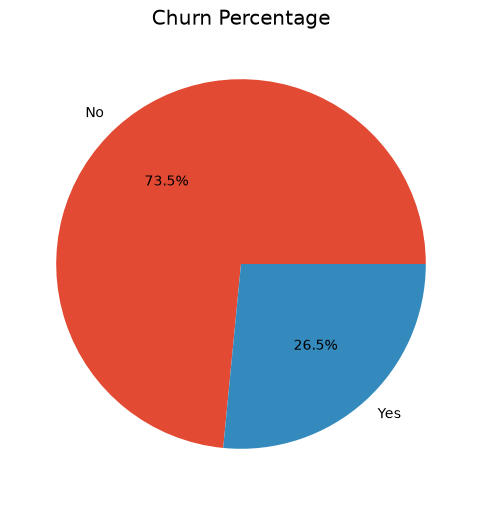

In [21]:
df["Churn"].value_counts().plot(
kind="pie",
autopct="%1.1f%%",
figsize=(6,6)
)
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

Chart 3
Histogram

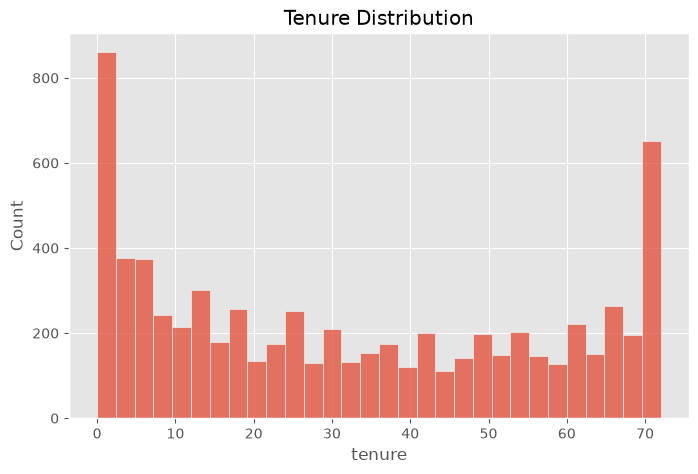

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Tenure Distribution")
plt.show()

Chart 4
Boxplot

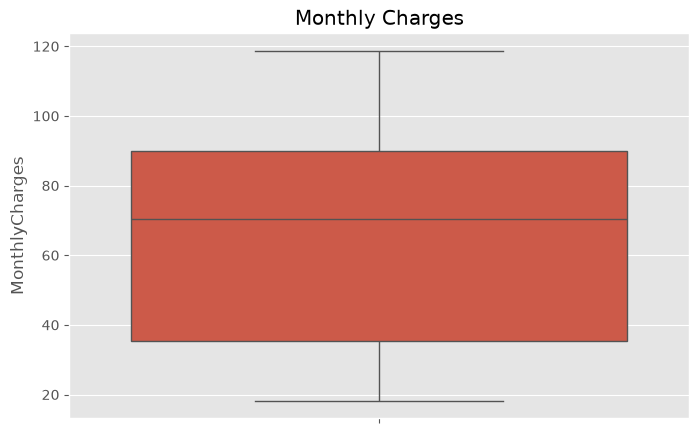

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Monthly Charges")
plt.show()

Chart 5
Contract Type

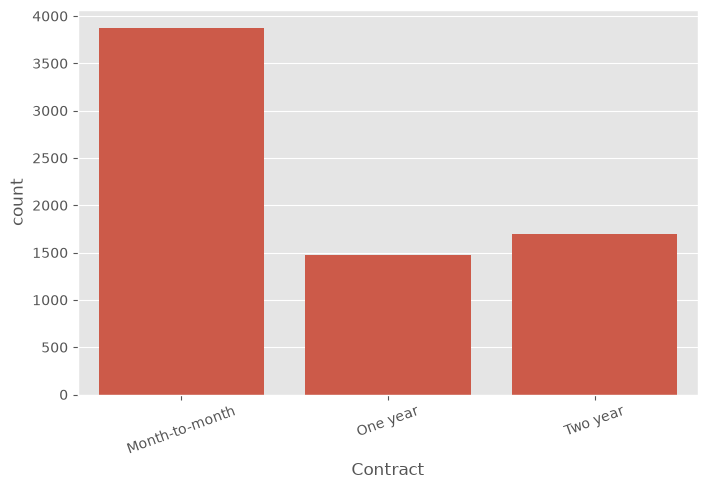

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", data=df)
plt.xticks(rotation=20)
plt.show()

Chart 6
Contract vs Churn

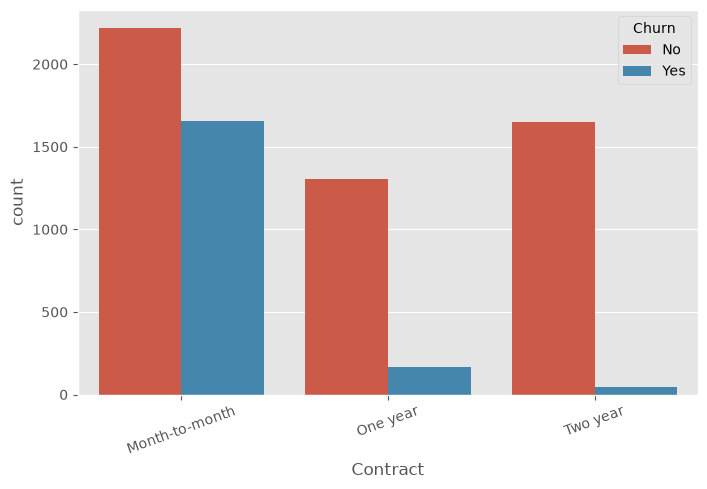

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

Chart 7
Heatmap

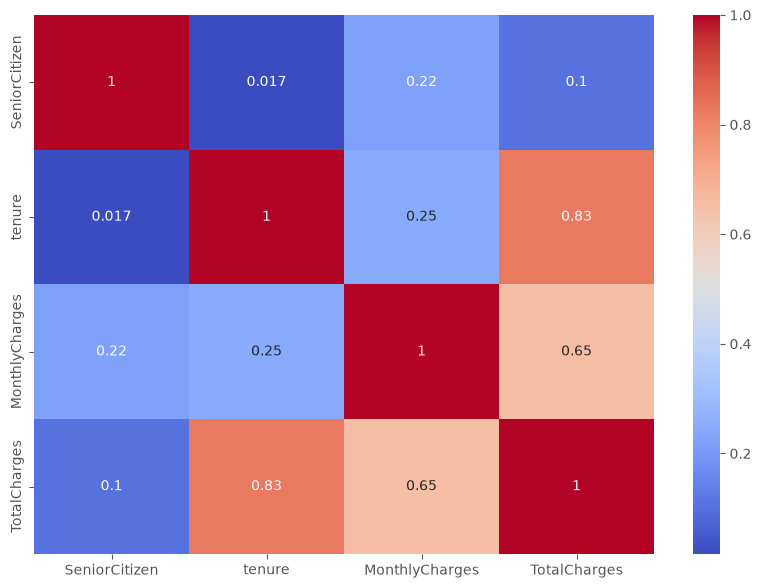

In [26]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(
numeric.corr(),
annot=True,
cmap="coolwarm"
)
plt.show()

Chart 8
Scatter Plot

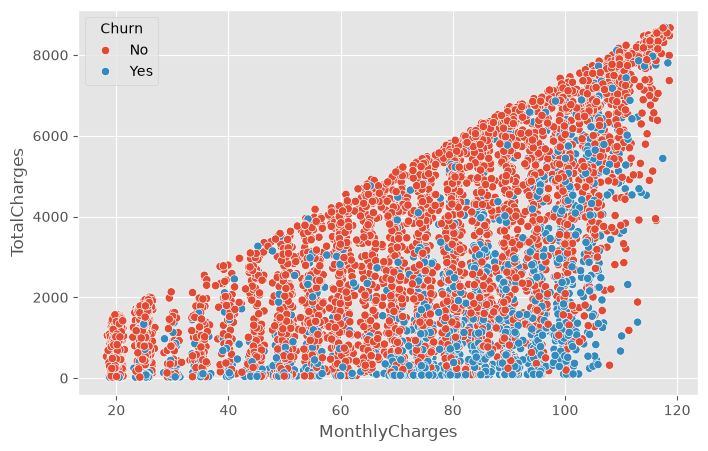

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
x="MonthlyCharges",
y="TotalCharges",
hue="Churn",
data=df
)
plt.show()

Business Questions
1 Percentage Churn

In [28]:
(df["Churn"].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

2 Highest Churn Group

In [29]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


3 Numerical Features

In [30]:
df.groupby("Churn")[["MonthlyCharges","TotalCharges","tenure"]].mean()

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.265124,2555.344141,37.569965
Yes,74.441332,1531.796094,17.979133


4 Categorical Features

In [31]:
pd.crosstab(df["InternetService"],df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


5 Missing Values

In [32]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

6 Outliers

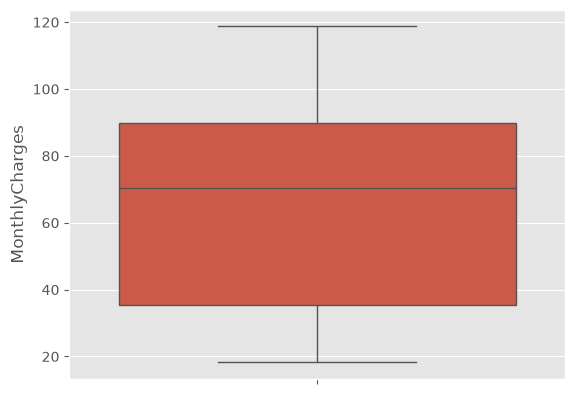

In [34]:
sns.boxplot(y=df["MonthlyCharges"])
plt.show()

Final Insights

1. Around 26% customers churn.

2. Month-to-month customers churn the most.

3. Customers with shorter tenure leave more often.

4. High monthly charges increase churn probability.

5. Fiber optic users have relatively higher churn.

6. No significant missing values remain after cleaning.

7. Tenure, contract type and monthly charges are the top factors affecting churn.

8. Offering discounts to month-to-month customers and encouraging long-term contracts can help reduce churn.